# Złożony workflow w Langgraph

Pipeline do **korekty draftu e-maila**. Przyjmuje surowy tekst i:

1. Sprawdza czy tekst jest wystarczająco długi – jeśli nie, LLM dopisuje dwa zdania i wraca do sprawdzenia **(cykl)**
2. Gdy tekst jest OK – uruchamia sprawdzenie gramatyki i tonu jednocześnie **(równoległe node'y)**
3. Na podstawie wyników gramatyki decyduje czy poprawić tekst czy zakończyć **(conditional routing)**

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## Pipeline state

Stan przechowuje bieżący tekst, licznik rozbudowań (do kontroli cyklu),
wyniki obu równoległych sprawdzeń oraz finalny raport.

In [2]:
from typing import Any, TypedDict


class State(TypedDict):
    text: str
    word_count: int
    expand_count: int
    grammar_notes: dict[str, Any]
    tone_notes: dict[str, Any]
    review_decision: dict[str, Any]
    report: str

## Logika przejść (if)

Mamy dwa warunki `if`:
- po `check_length`: czy tekst jest za krótki (`expand_text`) czy wystarczający (`start_parallel`)
- po `build_report`: decyzja opiera się na `review_decision.needs_fix` (structured output JSON)

In [4]:
from langchain_core.runnables import RunnableConfig

debug = True


def next_after_length(state: State, config: RunnableConfig) -> str:
    configurable = config.get("configurable", {})
    min_words = configurable.get("min_words", 60)
    max_expansions = configurable.get("max_expansions", 3)

    word_count = state["word_count"]
    should_expand = word_count < min_words and state["expand_count"] < max_expansions

    if should_expand:
        if debug:
            print(f"IF length: {word_count} < {min_words} i limit nieprzekroczony -> expand_text\n")
        return "expand_text"
    else:
        if debug:
            print(f"IF length: przejście do start_parallel (slowa={word_count}, expand_count={state['expand_count']})\n")
        return "start_parallel"


def next_after_review(state: State) -> str:
    needs_fix = bool(state.get("review_decision", {}).get("needs_fix", False))

    if needs_fix:
        if debug:
            print("IF review: needs_fix=true -> fix_text\n")
        return "fix_text"
    else:
        if debug:
            print("IF review: needs_fix=false -> END\n")
        return "end"

## Node'y

Pipeline ma 7 node'ów:
1. **check_length** - sprawdza długość tekstu (bez LLM), po nim `if`
2. **expand_text** - LLM dopisuje dwa zdania do tekstu (cel cyklu)
3. **start_parallel** - punkt startowy równoległych gałęzi
4. **check_grammar** - LLM sprawdza gramatykę (równolegle z `check_tone`)
5. **check_tone** - LLM ocenia ton e-maila (równolegle z `check_grammar`)
6. **build_report** - synchronizuje wyniki obu gałęzi i buduje raport; po nim `if`
7. **fix_text** - LLM poprawia błędy gramatyczne (bez dodatkowych cykli)

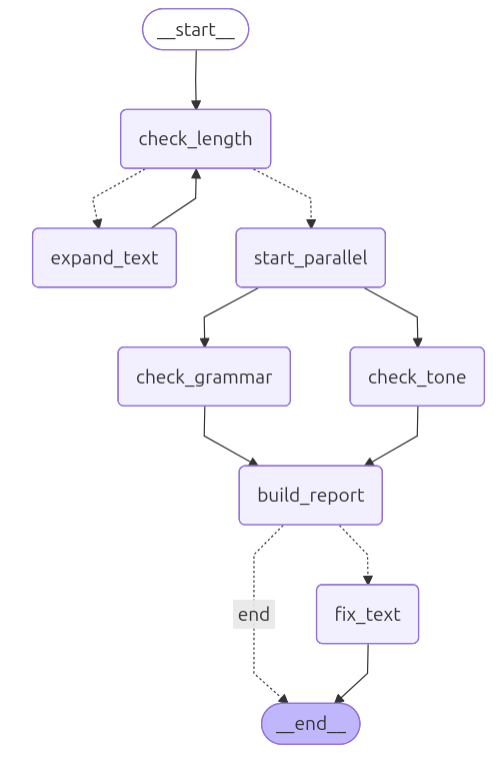

In [5]:
import json
from langchain_openai import ChatOpenAI

In [6]:
def check_length_node(state: State):
    word_count = len(state["text"].split())
    if debug:
        print(f"Node: check_length | {word_count} słów | expand_count={state['expand_count']}\n")
    return {"word_count": word_count}

In [7]:
def expand_text_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: expand_text | dopisywanie dwóch zdań...\n")

    configurable = config.get("configurable", {})
    model_name = configurable.get("model_name", "openai/gpt-4o-mini")

    llm = ChatOpenAI(model=model_name)

    response = llm.invoke([
        {
            "role": "system",
            "content": (
                "Dopisz dokładnie dwa zdania do poniższego szkicu e-maila, rozwijając jego treść. "
                "Zachowaj profesjonalny ton. Pisz po polsku. Zwróć wyłącznie pełny tekst e-maila."
            ),
        },
        {"role": "user", "content": state["text"]},
    ])

    return {
        "text": response.content,
        "expand_count": state.get("expand_count", 0) + 1,
    }

In [8]:
def start_parallel_node(state: State) -> dict:
    """Pass-through – punkt startowy równoległych gałęzi. Nie modyfikuje stanu."""
    if debug:
        word_count = len(state["text"].split())
        print(f"Node: start_parallel | tekst gotowy ({word_count} słów) → uruchamianie check_grammar i check_tone\n")
    return {}

In [9]:
from pydantic import BaseModel, Field

In [10]:
class GrammarCheck(BaseModel):
    has_errors: bool = Field(description="Czy tekst zawiera błędy gramatyczne/interpunkcyjne")
    issues: list[str] = Field(default_factory=list, description="Krótka lista znalezionych błędów")


def check_grammar_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: check_grammar [równolegle, structured JSON]\n")

    configurable = config.get("configurable", {})
    model_name = configurable.get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0).with_structured_output(GrammarCheck)

    response = llm.invoke([
        {
            "role": "system",
            "content": (
                "Sprawdź gramatykę i interpunkcję tekstu po polsku. "
                "Zwróć WYŁĄCZNIE poprawny JSON o schemacie: "
                '{"has_errors": boolean, "issues": [string, ...]}. '
                "Jeśli nie ma błędów, ustaw has_errors=false i issues=[]."
            ),
        },
        {"role": "user", "content": state["text"]},
    ])

    # parsed = response.output_parsed
    return {"grammar_notes": response.model_dump()}

In [11]:
class ToneCheck(BaseModel):
    tone_label: str = Field(description="Krótka etykieta tonu, np. profesjonalny/zbyt formalny")
    suggestion: str = Field(description="Jednozdaniowa sugestia poprawy tonu")


def check_tone_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: check_tone [równolegle, structured JSON]\n")
    configurable = config.get("configurable", {})
    model_name = configurable.get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0).with_structured_output(ToneCheck)
    response = llm.invoke([
        {
            "role": "system",
            "content": "Oceń ton tekstu. Przypisz mu etykietę oraz zasugeruj jego poprawę"
        },
        {"role": "user", "content": state["text"]},
    ])
    # parsed = response.output_parsed
    return {"tone_notes": response.model_dump()}

In [12]:
class ReviewDecision(BaseModel):
    needs_fix: bool = Field(description="Czy tekst wymaga poprawy gramatycznej")
    reason: str = Field(description="Krótki powód decyzji")


def build_report_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: build_report | synchronizacja wyników gramatyki i tonu\n")
    configurable = config.get("configurable", {})
    model_name = configurable.get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0).with_structured_output(ReviewDecision)
    response = llm.invoke([
        {
            "role": "system",
            "content": (
                "Na podstawie pola grammar_notes zdecyduj, czy tekst wymaga poprawy gramatycznej. "
                "Jeśli grammar_notes.has_errors=true, needs_fix ma być true. Uzasadnij decyzję."
            ),
        },
        {
            "role": "user",
            "content": json.dumps({"grammar_notes": state["grammar_notes"]}, ensure_ascii=False),
        },
    ])
    # parsed = response.output_parsed
    review_decision = response.model_dump()

    report = (
        f"=== Raport korekty e-maila ({model_name}) ===\n"
        f"Liczba rozbudowań: {state['expand_count']}\n"
        f"\n[Gramatyka - JSON]\n{state['grammar_notes']}\n"
        f"\n[Ton - JSON]\n{state['tone_notes']}\n"
        f"\n[Decyzja - JSON]\n{review_decision}\n"
        f"\n[Tekst końcowy]\n{state['text']}"
    )
    return {"report": report, "review_decision": review_decision}

In [13]:
def fix_text_node(state: State, config: RunnableConfig):
    if debug:
        print("Node: fix_text | poprawianie błędów gramatycznych\n")

    configurable = config.get("configurable", {})
    model_name = configurable.get("model_name", "openai/gpt-4o-mini")
    llm = ChatOpenAI(model=model_name, temperature=0, max_tokens=512)
    issues = state.get("grammar_notes", {}).get("issues", [])
    response = llm.invoke([
        {
            "role": "system",
            "content": "Popraw błędy gramatyczne w poniższym e-mailu. Zwróć wyłącznie poprawiony tekst.",
        },
        {
            "role": "user",
            "content": f"Tekst:\n{state['text']}\n\nBłędy do poprawy:\n{issues}",
        },
    ])
    fixed_report = state["report"] + f"\n\n[Po korekcie gramatycznej]\n{response.content}"
    return {"text": response.content, "report": fixed_report}

## State graph

- Jeden cykl: `expand_text -> check_length`
- Jedno zrównoleglenie: `start_parallel -> check_grammar` i `start_parallel -> check_tone`
- Jawne `if` po `check_length` i po `build_report`


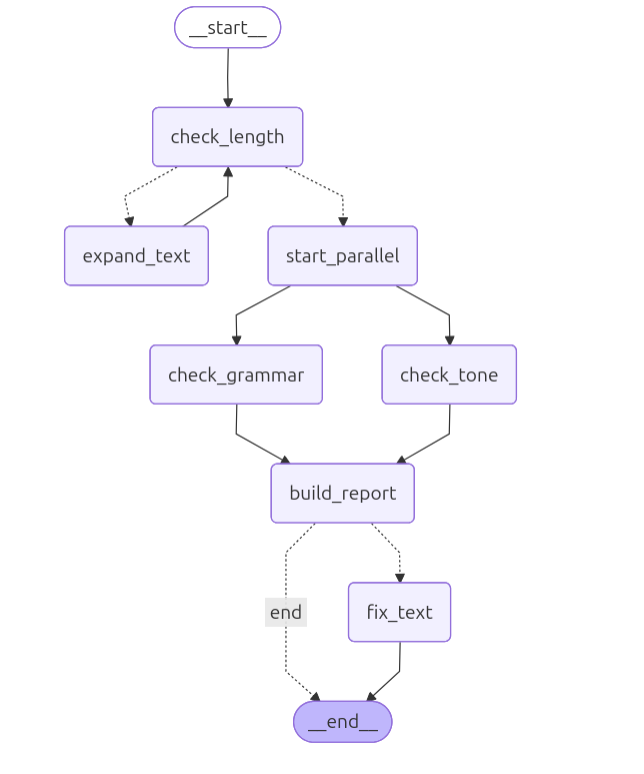

In [14]:
from langgraph.graph import StateGraph, START, END

In [15]:
graph = StateGraph(State)

graph.add_node("check_length", check_length_node)
graph.add_node("expand_text", expand_text_node)
graph.add_node("start_parallel", start_parallel_node)
graph.add_node("check_grammar", check_grammar_node)
graph.add_node("check_tone", check_tone_node)
graph.add_node("build_report", build_report_node)
graph.add_node("fix_text", fix_text_node)

graph.add_edge(START, "check_length")

graph.add_conditional_edges(
    "check_length",
    next_after_length,
    {"expand_text": "expand_text", "start_parallel": "start_parallel"},
)
graph.add_edge("expand_text", "check_length")          # ← zamknięcie cyklu
graph.add_edge("start_parallel", "check_grammar")
graph.add_edge("start_parallel", "check_tone")
graph.add_edge("check_grammar", "build_report")
graph.add_edge("check_tone", "build_report")
graph.add_conditional_edges(
    "build_report",
    next_after_review,
    {"fix_text": "fix_text", "end": END},
)
graph.add_edge("fix_text", END)

pipeline = graph.compile()

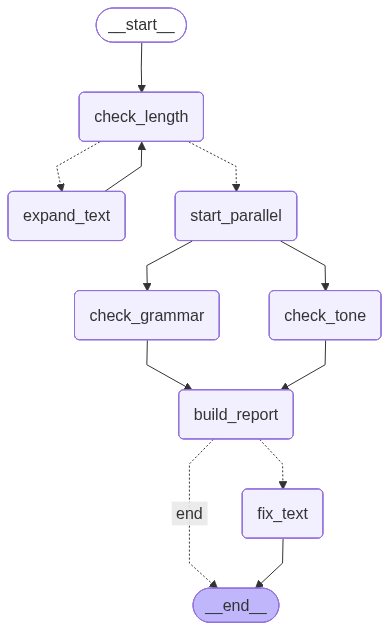

In [16]:
pipeline

In [ ]:
from IPython.display import Markdown, display

mermaid = pipeline.get_graph().draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid}\n```"))


## Uruchomienie pipeline'u

### Przykład 1 – tekst za krótki (widoczny cykl)

Bardzo krótki szkic wymusi wielokrotne przejście przez `expand_text → check_length`.
`expand_text` dopisuje dwa zdania naraz (mały `max_tokens`), więc przy `min_words=60`
cykl wykona się co najmniej dwa razy zanim tekst osiągnie wymaganą długość.

In [17]:
runtime_config = {
    "configurable": {
        "model_name": "openai/gpt-4o-mini",
        "min_words": 60,
        "max_expansions": 4,
    }
}
initial_state = {
    "text": "Dzień dobry. Pytam o zamówienie nr 123.",
    "word_count": None,
    "expand_count": 0,
    "grammar_notes": {},
    "tone_notes": {},
    "review_decision": {},
    "report": "",
}

result = pipeline.invoke(initial_state, config=runtime_config)

Node: check_length | 7 słów | expand_count=0

IF length: 7 < 60 i limit nieprzekroczony -> expand_text

Node: expand_text | dopisywanie dwóch zdań...

Node: check_length | 38 słów | expand_count=1

IF length: 38 < 60 i limit nieprzekroczony -> expand_text

Node: expand_text | dopisywanie dwóch zdań...

Node: check_length | 49 słów | expand_count=2

IF length: 49 < 60 i limit nieprzekroczony -> expand_text

Node: expand_text | dopisywanie dwóch zdań...

Node: check_length | 69 słów | expand_count=3

IF length: przejście do start_parallel (slowa=69, expand_count=3)

Node: start_parallel | tekst gotowy (69 słów) → uruchamianie check_grammar i check_tone

Node: check_grammar [równolegle, structured JSON]

Node: check_tone [równolegle, structured JSON]

Node: build_report | synchronizacja wyników gramatyki i tonu

IF review: needs_fix=false -> END



In [18]:
print(result["report"])

=== Raport korekty e-maila (openai/gpt-4o-mini) ===
Liczba rozbudowań: 3

[Gramatyka - JSON]
{'has_errors': False, 'issues': []}

[Ton - JSON]
{'tone_label': 'profesjonalny', 'suggestion': 'Ton jest odpowiedni, ale można dodać więcej uprzejmości, na przykład poprzez wyrażenie nadziei na szybkie rozwiązanie sprawy.'}

[Decyzja - JSON]
{'needs_fix': False, 'reason': 'Tekst nie zawiera błędów gramatycznych.'}

[Tekst końcowy]
Dzień dobry,

Pytam o zamówienie nr 123. Chciałbym uzyskać informacje na temat statusu realizacji oraz przewidywanego terminu dostawy. Ponadto, jeśli wystąpiły jakiekolwiek opóźnienia, proszę o informację na temat przyczyn. Zależy mi na jak najszybszym rozwiązaniu tej sprawy, dlatego będę wdzięczny za możliwie najszybszą odpowiedź. Dziękuję z góry za Państwa pomoc i zaangażowanie w tę kwestię.

Z poważaniem,  
[Twoje Imię i Nazwisko]  
[Twoja Firma]  
[Twój Numer Telefonu]  
[Twój Adres E-mail]


In [19]:
result

{'text': 'Dzień dobry,\n\nPytam o zamówienie nr 123. Chciałbym uzyskać informacje na temat statusu realizacji oraz przewidywanego terminu dostawy. Ponadto, jeśli wystąpiły jakiekolwiek opóźnienia, proszę o informację na temat przyczyn. Zależy mi na jak najszybszym rozwiązaniu tej sprawy, dlatego będę wdzięczny za możliwie najszybszą odpowiedź. Dziękuję z góry za Państwa pomoc i zaangażowanie w tę kwestię.\n\nZ poważaniem,  \n[Twoje Imię i Nazwisko]  \n[Twoja Firma]  \n[Twój Numer Telefonu]  \n[Twój Adres E-mail]',
 'word_count': 69,
 'expand_count': 3,
 'grammar_notes': {'has_errors': False, 'issues': []},
 'tone_notes': {'tone_label': 'profesjonalny',
  'suggestion': 'Ton jest odpowiedni, ale można dodać więcej uprzejmości, na przykład poprzez wyrażenie nadziei na szybkie rozwiązanie sprawy.'},
 'review_decision': {'needs_fix': False,
  'reason': 'Tekst nie zawiera błędów gramatycznych.'},
 'report': "=== Raport korekty e-maila (openai/gpt-4o-mini) ===\nLiczba rozbudowań: 3\n\n[Gramat

### Przykład 2 – tekst wystarczająco długi

Dłuższy tekst pomija cykl i od razu trafia do równoległego sprawdzenia.

In [20]:
initial_state_long = {
    "text": (
        "Szanowni Państwo, chciałbym zgłosić problem z zamówieniem numer 12345, które miało zostać dostarczone do 15 maja 2026 roku. "
        "Do dzisiaj nie otrzymałem żadnej informacji o opóźnieniu i nie wiem, kiedy paczka zostanie doręczona, co utrudnia mi zaplanowanie dalszych działań. "
        "Bardzo proszę o pilne sprawdzenie statusu przesyłki oraz wysłanie mi aktualizacji na ten temat, ponieważ sytuacja są dla mnie bardzo kłopotliwe. "
        "Dodatkowo proszę o podanie przewidywanej daty dostawy i numeru kontaktowego do osoby, który mogą potwierdzić szczegóły. "
        "Z góry dziękuję za szybką odpowiedź i liczę, że sprawa zostanie rozwiązane możliwie szybko."
    ),
    "word_count": None,
    "expand_count": 0,
    "grammar_notes": {},
    "tone_notes": {},
    "review_decision": {},
    "report": "",
}

result_long = pipeline.invoke(initial_state_long, config=runtime_config)

Node: check_length | 90 słów | expand_count=0

IF length: przejście do start_parallel (slowa=90, expand_count=0)

Node: start_parallel | tekst gotowy (90 słów) → uruchamianie check_grammar i check_tone

Node: check_grammar [równolegle, structured JSON]

Node: check_tone [równolegle, structured JSON]

Node: build_report | synchronizacja wyników gramatyki i tonu

IF review: needs_fix=true -> fix_text

Node: fix_text | poprawianie błędów gramatycznych



In [21]:
print(result_long["report"])

=== Raport korekty e-maila (openai/gpt-4o-mini) ===
Liczba rozbudowań: 0

[Gramatyka - JSON]
{'has_errors': True, 'issues': ['"sytuacja są dla mnie bardzo kłopotliwe" - powinno być "sytuacja jest dla mnie bardzo kłopotliwa"', '"do osoby, który mogą potwierdzić szczegóły" - powinno być "do osoby, która może potwierdzić szczegóły"', '"sprawa zostanie rozwiązane" - powinno być "sprawa zostanie rozwiązana"']}

[Ton - JSON]
{'tone_label': 'formalny', 'suggestion': 'Można złagodzić ton, dodając więcej uprzejmości i wyrażając zrozumienie dla sytuacji firmy.'}

[Decyzja - JSON]
{'needs_fix': True, 'reason': 'Tekst zawiera błędy gramatyczne, które wymagają poprawy, takie jak błędna forma czasownika i użycie niewłaściwego zaimka.'}

[Tekst końcowy]
Szanowni Państwo, chciałbym zgłosić problem z zamówieniem numer 12345, które miało zostać dostarczone do 15 maja 2026 roku. Do dzisiaj nie otrzymałem żadnej informacji o opóźnieniu i nie wiem, kiedy paczka zostanie doręczona, co utrudnia mi zaplanowan

In [22]:
result_long

{'text': 'Szanowni Państwo, chciałbym zgłosić problem z zamówieniem numer 12345, które miało zostać dostarczone do 15 maja 2026 roku. Do dzisiaj nie otrzymałem żadnej informacji o opóźnieniu i nie wiem, kiedy paczka zostanie doręczona, co utrudnia mi zaplanowanie dalszych działań. Bardzo proszę o pilne sprawdzenie statusu przesyłki oraz wysłanie mi aktualizacji na ten temat, ponieważ sytuacja jest dla mnie bardzo kłopotliwa. Dodatkowo proszę o podanie przewidywanej daty dostawy i numeru kontaktowego do osoby, która może potwierdzić szczegóły. Z góry dziękuję za szybką odpowiedź i liczę, że sprawa zostanie rozwiązana możliwie szybko.',
 'word_count': 90,
 'expand_count': 0,
 'grammar_notes': {'has_errors': True,
  'issues': ['"sytuacja są dla mnie bardzo kłopotliwe" - powinno być "sytuacja jest dla mnie bardzo kłopotliwa"',
   '"do osoby, który mogą potwierdzić szczegóły" - powinno być "do osoby, która może potwierdzić szczegóły"',
   '"sprawa zostanie rozwiązane" - powinno być "sprawa 

> **ZADANIA**